(Bayesian Vector Autoregressive Models)=
# Bayesian Vector Autoregressive Models

:::{post} November, 2022
:tags: time series, vector autoregressive model, hierarchical model
:category: intermediate
:author: Nathaniel Forde
:::

In [1]:
import os

import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import statsmodels.api as sm
from pymc.sampling.jax import sample_blackjax_nuts

In [2]:
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
azp.style.use("plotly")
%config InlineBackend.figure_format = 'retina'

## V(ector)A(uto)R(egression) Models 

In this notebook we will outline an application of the Bayesian Vector Autoregressive Modelling. We will draw on the work in the PYMC Labs [blogpost](https://www.pymc-labs.io/blog-posts/bayesian-vector-autoregression/) (see {cite:t}`vieira2022BVAR`). This will be a three part series. In the first we want to show how to fit Bayesian VAR models in PYMC. In the second we will show how to extract extra insight from the fitted model with Impulse Response analysis and make forecasts from the fitted VAR model. In the third and final post we will show in some more detail the benefits of using hierarchical priors with Bayesian VAR models. Specifically, we'll outline how and why there are actually a range of carefully formulated industry standard priors which work with Bayesian VAR modelling. 

In this post we will (i) demonstrate the basic pattern on a simple VAR model on fake data and show how the model recovers the true data generating parameters and (ii) we will show an example applied to macro-economic data and compare the results to those achieved on the same data with statsmodels MLE fits and (iii) show an example of estimating a hierarchical bayesian VAR model over a number of countries.  

## Autoregressive Models in General

The idea of a simple autoregressive model is to capture the manner in which past observations of the timeseries are predictive of the current observation. So in traditional fashion, if we model this as a linear phenomena we get simple autoregressive models where the current value is predicted by a weighted linear combination of the past values and an error term. 

$$ y_t = \alpha + \beta_{y0} \cdot y_{t-1} + \beta_{y1} \cdot y_{t-2} ... + \epsilon $$

for however many lags are deemed appropriate to the predict the current observation. 

A VAR model is kind of generalisation of this framework in that it retains the linear combination approach but allows us to model multiple timeseries at once. So concretely this mean that $\mathbf{y}_{t}$ as a vector where:

$$ \mathbf{y}_{T} =  \nu + A_{1}\mathbf{y}_{T-1} + A_{2}\mathbf{y}_{T-2} ... A_{p}\mathbf{y}_{T-p} + \mathbf{e}_{t}  $$

where the As are coefficient matrices to be combined with the past values of each individual timeseries. For example consider an economic example where we aim to model the relationship and mutual influence of each variable on themselves and one another.

$$ \begin{bmatrix} gdp \\ inv \\ con \end{bmatrix}_{T} = \nu + A_{1}\begin{bmatrix} gdp \\ inv \\ con \end{bmatrix}_{T-1} + 
    A_{2}\begin{bmatrix} gdp \\ inv \\ con \end{bmatrix}_{T-2} ... A_{p}\begin{bmatrix} gdp \\ inv \\ con \end{bmatrix}_{T-p} + \mathbf{e}_{t} $$

This structure is compact representation using matrix notation. The thing we are trying to estimate when we fit a VAR model is the A matrices that determine the nature of the linear combination that best fits our timeseries data. Such timeseries models can have an auto-regressive or a moving average representation, and the details matter for some of the implication of a VAR model fit. 

We'll see in the next notebook of the series how the moving-average representation of a VAR lends itself to the interpretation of the covariance structure in our model as representing a kind of impulse-response relationship between the component timeseries. 

### A Concrete Specification with Two lagged Terms

The matrix notation is convenient to suggest the broad patterns of the model, but it is useful to see the algebra is a simple case. Consider the case of Ireland's GDP and consumption described as: 

$$ gdp_{t} = \beta_{gdp1} \cdot gdp_{t-1} + \beta_{gdp2} \cdot gdp_{t-2} +  \beta_{cons1} \cdot cons_{t-1} + \beta_{cons2} \cdot cons_{t-2}  + \epsilon_{gdp}$$
$$ cons_{t} = \beta_{cons1} \cdot cons_{t-1} + \beta_{cons2} \cdot cons_{t-2} +  \beta_{gdp1} \cdot gdp_{t-1} + \beta_{gdp2} \cdot gdp_{t-2}  + \epsilon_{cons}$$

In this way we can see that if we can estimate the $\beta$ terms we have an estimate for the bi-directional effects of each variable on the other. This is a useful feature of the modelling. In what follows i should stress that i'm not an economist and I'm aiming to show only the functionality of these models not give you a decisive opinion about the economic relationships determining Irish GDP figures. 

### Creating some Fake Data

In [3]:
def simulate_var(
        intercepts, coefs_yy, coefs_xy, coefs_xx, coefs_yx, noises=(1, 1), *, warmup=100, steps=200
):
    draws_y = np.zeros(warmup + steps)
    draws_x = np.zeros(warmup + steps)
    draws_y[:2] = intercepts[0]
    draws_x[:2] = intercepts[1]
    for step in range(2, warmup + steps):
        draws_y[step] = (
                intercepts[0]
                + coefs_yy[0] * draws_y[step - 1]
                + coefs_yy[1] * draws_y[step - 2]
                + coefs_xy[0] * draws_x[step - 1]
                + coefs_xy[1] * draws_x[step - 2]
                + rng.normal(0, noises[0])
        )
        draws_x[step] = (
                intercepts[1]
                + coefs_xx[0] * draws_x[step - 1]
                + coefs_xx[1] * draws_x[step - 2]
                + coefs_yx[0] * draws_y[step - 1]
                + coefs_yx[1] * draws_y[step - 2]
                + rng.normal(0, noises[1])
        )
    return draws_y[warmup:], draws_x[warmup:]

First we generate some fake data with known parameters.

In [4]:
var_y, var_x = simulate_var(
    intercepts=(18, 8),
    coefs_yy=(-0.8, 0),
    coefs_xy=(0.9, 0),
    coefs_xx=(1.3, -0.7),
    coefs_yx=(-0.1, 0.3),
)

df = pd.DataFrame({"x": var_x, "y": var_y})
df.head()

,x,y
0,34.606613,30.117581
1,34.773803,23.996700
2,35.455237,29.738941
3,33.886706,27.193417
4,31.837465,26.704728


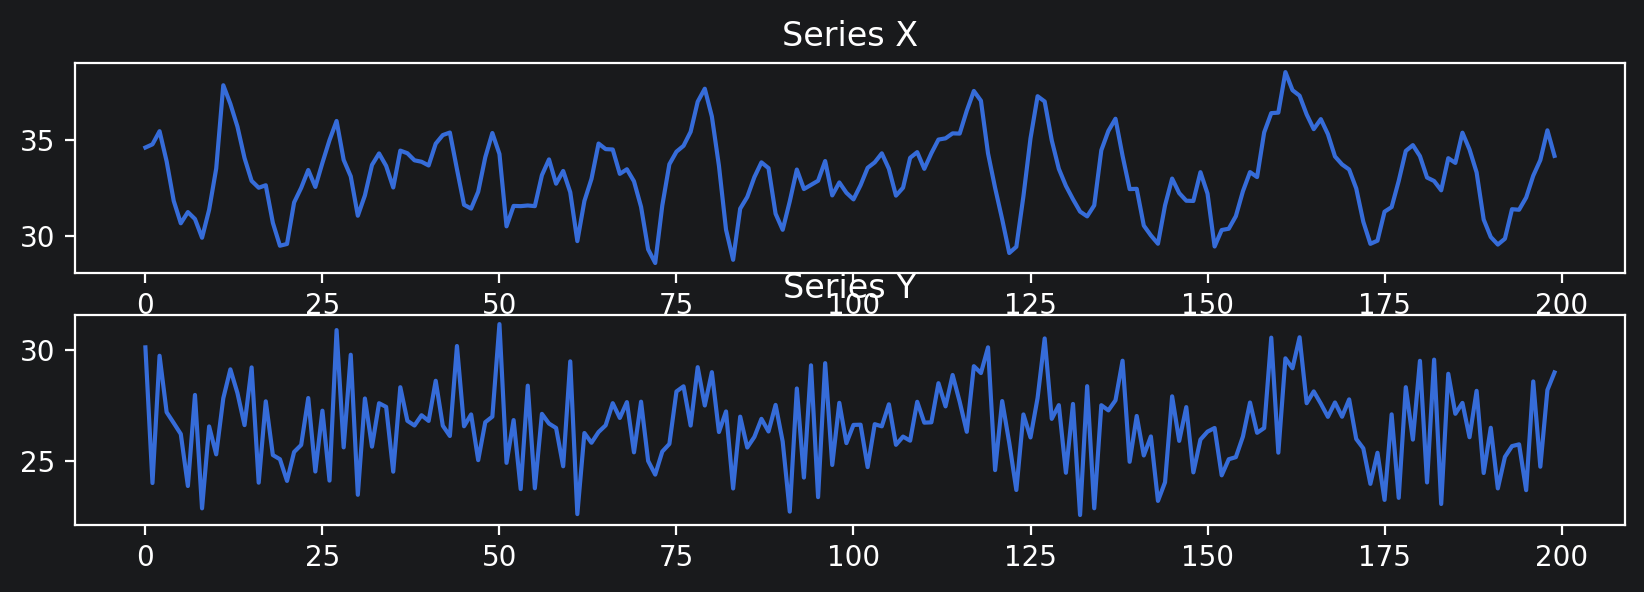

In [5]:
fig, axs = plt.subplots(2, 1, figsize=(10, 3))
axs[0].plot(df["x"], label="x")
axs[0].set_title("Series X")
axs[1].plot(df["y"], label="y")
axs[1].set_title("Series Y");

## Handling Multiple Lags and Different Dimensions

When Modelling multiple timeseries and accounting for potentially any number lags to incorporate in our model we need to abstract some of the model definition to helper functions. An example will make this a bit clearer.

In [6]:
### Define a helper function that will construct our autoregressive step for the marginal contribution of each lagged
### term in each of the respective time series equations
def calc_ar_step(lag_coefs, n_eqs, n_lags, df):
    ars = []
    for j in range(n_eqs):
        ar = pm.math.sum(
            [
                pm.math.sum(lag_coefs[j, i] * df.values[n_lags - (i + 1): -(i + 1)], axis=-1)
                for i in range(n_lags)
            ],
            axis=0,
        )
        ars.append(ar)
    beta = pm.math.stack(ars, axis=-1)

    return beta


### Make the model in such a way that it can handle different specifications of the likelihood term
### and can be run for simple prior predictive checks. This latter functionality is important for debugging of
### shape handling issues. Building a VAR model involves quite a few moving parts and it is handy to
### inspect the shape implied in the prior predictive checks.
def make_model(n_lags, n_eqs, df, priors, mv_norm=True, prior_checks=True):
    coords = {
        "lags": np.arange(n_lags) + 1,
        "equations": df.columns.tolist(),
        "cross_vars": df.columns.tolist(),
        "time": [x for x in df.index[n_lags:]],
    }

    with pm.Model(coords=coords) as model:
        lag_coefs = pm.Normal(
            "lag_coefs",
            mu=priors["lag_coefs"]["mu"],
            sigma=priors["lag_coefs"]["sigma"],
            dims=["equations", "lags", "cross_vars"],
        )
        alpha = pm.Normal(
            "alpha", mu=priors["alpha"]["mu"], sigma=priors["alpha"]["sigma"], dims=("equations",)
        )
        data_obs = pm.Data("data_obs", df.values[n_lags:], dims=["time", "equations"])

        betaX = calc_ar_step(lag_coefs, n_eqs, n_lags, df)
        betaX = pm.Deterministic(
            "betaX",
            betaX,
            dims=[
                "time",
                "equations",
            ],
        )
        mean = alpha + betaX

        if mv_norm:
            n = df.shape[1]
            ## Under the hood the LKJ prior will retain the correlation matrix too.
            noise_chol, _, _ = pm.LKJCholeskyCov(
                "noise_chol",
                eta=priors["noise_chol"]["eta"],
                n=n,
                sd_dist=pm.HalfNormal.dist(sigma=priors["noise_chol"]["sigma"]),
            )
            obs = pm.MvNormal(
                "obs", mu=mean, chol=noise_chol, observed=data_obs, dims=["time", "equations"]
            )
        else:
            ## This is an alternative likelihood that can recover sensible estimates of the coefficients
            ## But lacks the multivariate correlation between the timeseries.
            sigma = pm.HalfNormal("noise", sigma=priors["noise"]["sigma"], dims=["equations"])
            obs = pm.Normal(
                "obs", mu=mean, sigma=sigma, observed=data_obs, dims=["time", "equations"]
            )

        if prior_checks:
            idata = pm.sample_prior_predictive()
            return model, idata
        else:
            idata = pm.sample_prior_predictive()
            idata.extend(pm.sample(draws=2000, random_seed=130))
            pm.sample_posterior_predictive(idata, extend_inferencedata=True, random_seed=rng)
    return model, idata

The model has a deterministic component in the auto-regressive calculation which is required at each timestep, but the key point here is that we model the likelihood of the VAR as a multivariate normal distribution with a particular covariance relationship. The estimation of these covariance relationship gives the main insight in the manner in which our component timeseries relate to one another. 

We will inspect the structure of a VAR with 2 lags and 2 equations

Sampling: [alpha, lag_coefs, noise_chol, obs]


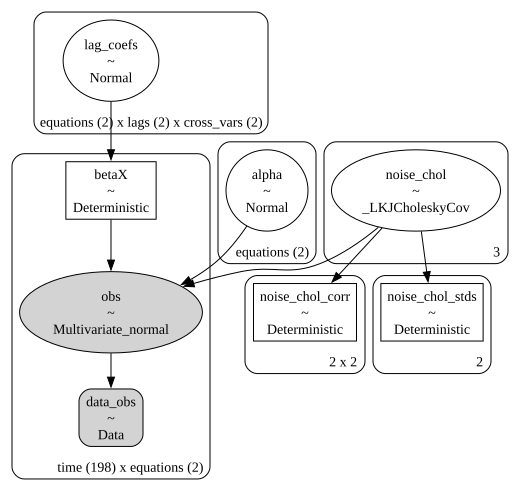

In [7]:
n_lags = 2
n_eqs = 2
priors = {
    "lag_coefs": {"mu": 0.3, "sigma": 1},
    "alpha": {"mu": 15, "sigma": 5},
    "noise_chol": {"eta": 1, "sigma": 1},
    "noise": {"sigma": 1},
}

model, idata = make_model(n_lags, n_eqs, df, priors)
pm.model_to_graphviz(model)

Another VAR with 3 lags and 2 equations.

Sampling: [alpha, lag_coefs, noise_chol, obs]


  lag_coefs: shape=(np.int64(2), np.int64(3), np.int64(2))
      alpha: shape=(np.int64(2),)
noise_chol_cholesky-cov-packed__: shape=(np.int64(3),)
 noise_chol: shape=(np.int64(3),)


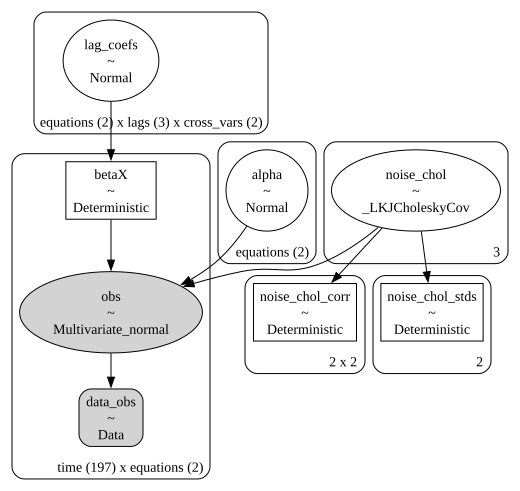

In [8]:
n_lags = 3
n_eqs = 2
model, idata = make_model(n_lags, n_eqs, df, priors)
for rv, shape in model.eval_rv_shapes().items():
    print(f"{rv:>11}: shape={shape}")
pm.model_to_graphviz(model)

We can inspect the correlation matrix between our timeseries which is implied by the prior specification, to see that we have allowed a flat uniform prior over their correlation.

C:\Users\markm\PML_Finance_Project\.venv\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: divide by zero encountered in divide
  return n / db / n.sum(), bin_edges
C:\Users\markm\PML_Finance_Project\.venv\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


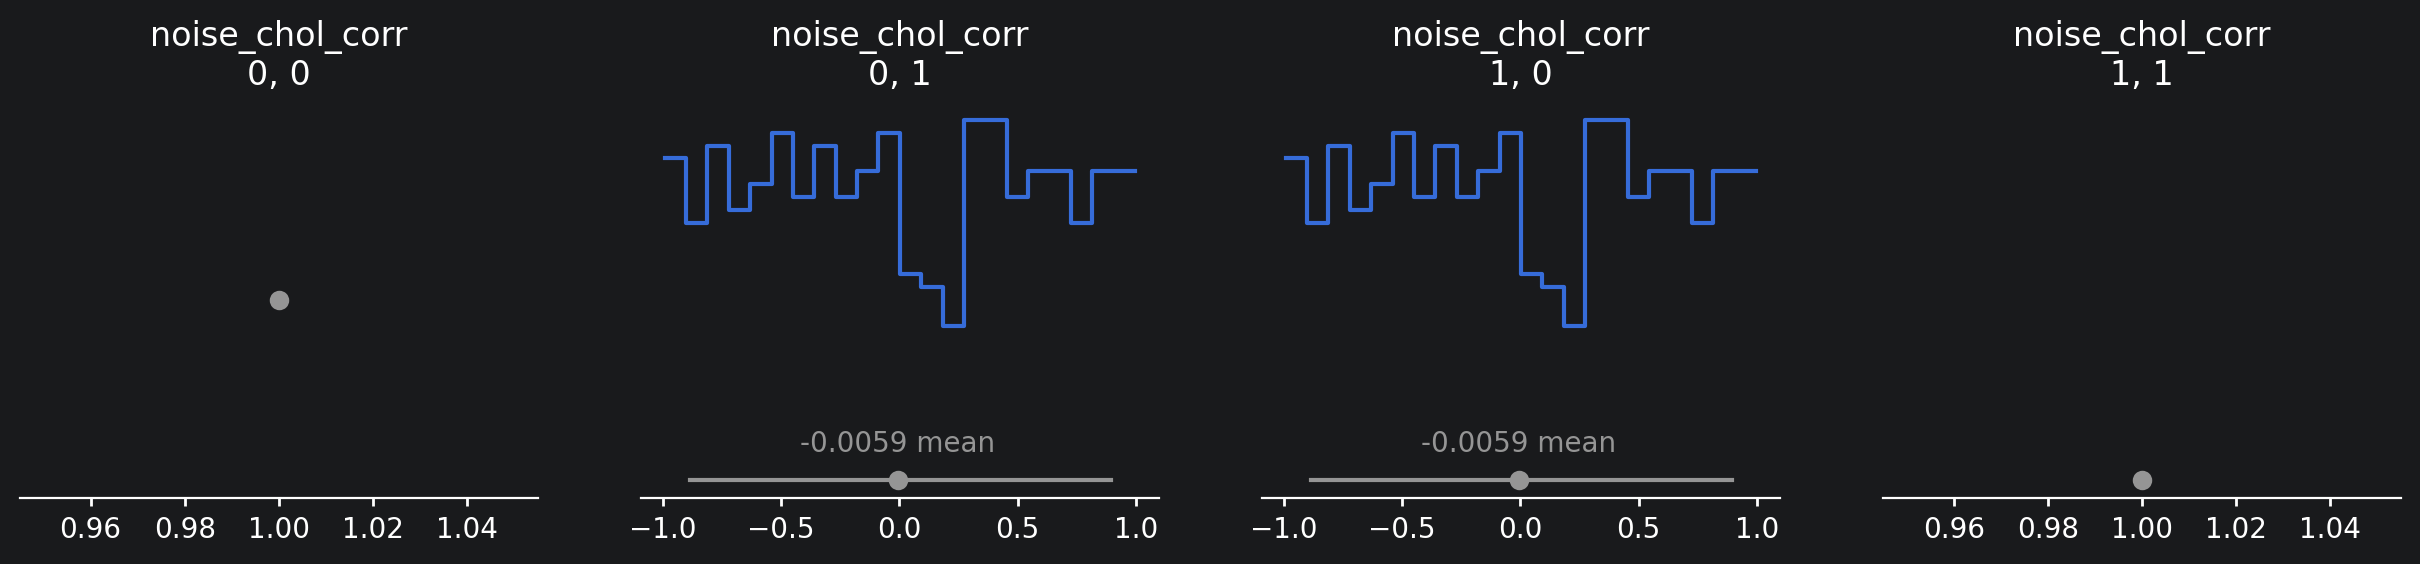

In [9]:
ax = azp.plot_dist(
    idata,
    var_names="noise_chol_corr",
    group="prior",
    point_estimate="mean",
    kind="hist",
)

Now we will fit the VAR with 2 lags and 2 equations

In [10]:
n_lags = 2
n_eqs = 2
model, idata_fake_data = make_model(n_lags, n_eqs, df, priors, prior_checks=False)

Sampling: [alpha, lag_coefs, noise_chol, obs]


AttributeError: 'DataTree' object has no attribute 'extend'

We'll now plot some of the results to see that the parameters are being broadly recovered. The alpha parameters match well, but the individual lag coefficients show differences.

In [ ]:
azs.summary(idata_fake_data, var_names=["alpha", "lag_coefs", "noise_chol_corr"])

In [ ]:
azp.plot_dist(idata_fake_data, var_names=["alpha"], ref_val=[8, 18]);

Next we'll plot the posterior predictive distribution to check that the fitted model can capture the patterns in the observed data. This is the primary test of goodness of fit.

In [ ]:
def shade_background(ppc, ax, idx, palette="cividis"):
    palette = palette
    cmap = plt.get_cmap(palette)
    percs = np.linspace(51, 99, 100)
    colors = (percs - np.min(percs)) / (np.max(percs) - np.min(percs))
    for i, p in enumerate(percs[::-1]):
        upper = np.percentile(
            ppc[:, idx, :],
            p,
            axis=1,
        )
        lower = np.percentile(
            ppc[:, idx, :],
            100 - p,
            axis=1,
        )
        color_val = colors[i]
        ax[idx].fill_between(
            x=np.arange(ppc.shape[0]),
            y1=upper.flatten(),
            y2=lower.flatten(),
            color=cmap(color_val),
            alpha=0.1,
        )


def plot_ppc(idata, df, group="posterior_predictive"):
    fig, axs = plt.subplots(2, 1, figsize=(25, 15))
    df = pd.DataFrame(idata_fake_data["observed_data"]["obs"].data, columns=["x", "y"])
    axs = axs.flatten()
    ppc = azb.extract(idata, group=group, num_samples=100)["obs"]
    # Minus the lagged terms and the constant
    shade_background(ppc, axs, 0, "inferno")
    axs[0].plot(np.arange(ppc.shape[0]), ppc[:, 0, :].mean(axis=1), color="cyan", label="Mean")
    axs[0].plot(df["x"], "o", mfc="black", mec="white", mew=1, markersize=7, label="Observed")
    axs[0].set_title("VAR Series 1")
    axs[0].legend()
    shade_background(ppc, axs, 1, "inferno")
    axs[1].plot(df["y"], "o", mfc="black", mec="white", mew=1, markersize=7, label="Observed")
    axs[1].plot(np.arange(ppc.shape[0]), ppc[:, 1, :].mean(axis=1), color="cyan", label="Mean")
    axs[1].set_title("VAR Series 2")
    axs[1].legend()


plot_ppc(idata_fake_data, df)

Again we can check the learned posterior distribution for the correlation parameter.

In [ ]:
ax = azp.plot_dist(
    idata_fake_data,
    var_names="noise_chol_corr",
    group="prior",
    point_estimate="mean",
    kind="hist",
)

## Applying the Theory: Macro Economic Timeseries

The data is from the World Bank’s World Development Indicators. In particular, we're pulling annual values of GDP, consumption, and gross fixed capital formation (investment) for all countries from 1970. Timeseries models in general work best when we have a stable mean throughout the series, so for the estimation procedure we have taken the first difference and the natural log of each of these series.

In [ ]:
try:
    gdp_hierarchical = pd.read_csv(
        os.path.join("..", "data", "gdp_data_hierarchical_clean.csv"), index_col=0
    )
except FileNotFoundError:
    gdp_hierarchical = pd.read_csv(pm.get_data("gdp_data_hierarchical_clean.csv"), ...)

gdp_hierarchical

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(20, 10))
for country in gdp_hierarchical["country"].unique():
    temp = gdp_hierarchical[gdp_hierarchical["country"] == country].reset_index()
    axs[0].plot(temp["dl_gdp"], label=f"{country}")
    axs[1].plot(temp["dl_cons"], label=f"{country}")
    axs[2].plot(temp["dl_gfcf"], label=f"{country}")
axs[0].set_title("Differenced and Logged GDP")
axs[1].set_title("Differenced and Logged Consumption")
axs[2].set_title("Differenced and Logged Investment")
axs[0].legend()
axs[1].legend()
axs[2].legend()
plt.suptitle("Macroeconomic Timeseries");

## Ireland's Economic Situation

Ireland is somewhat infamous for its GDP numbers that are largely the product of foreign direct investment and inflated beyond expectation in recent years by the investment and taxation deals offered to large multi-nationals. We'll look here at just the relationship between GDP and consumption. We just want to show the mechanics of the VAR estimation, you shouldn't read too much into the subsequent analysis.

In [ ]:
ireland_df = gdp_hierarchical[gdp_hierarchical["country"] == "Ireland"]
ireland_df.reset_index(inplace=True, drop=True)
ireland_df.head()

In [ ]:
n_lags = 2
n_eqs = 2
priors = {
    ## Set prior for expected positive relationship between the variables.
    "lag_coefs": {"mu": 0.3, "sigma": 1},
    "alpha": {"mu": 0, "sigma": 0.1},
    "noise_chol": {"eta": 1, "sigma": 1},
    "noise": {"sigma": 1},
}
model, idata_ireland = make_model(
    n_lags, n_eqs, ireland_df[["dl_gdp", "dl_cons"]], priors, prior_checks=False
)
idata_ireland

In [ ]:
azp.plot_trace(idata_ireland, var_names=["lag_coefs", "alpha", "betaX"], kind="rank_vlines");

In [ ]:
def plot_ppc_macro(idata, df, group="posterior_predictive"):
    df = pd.DataFrame(idata["observed_data"]["obs"].data, columns=["dl_gdp", "dl_cons"])
    fig, axs = plt.subplots(2, 1, figsize=(20, 10))
    axs = axs.flatten()
    ppc = azb.extract(idata, group=group, num_samples=100)["obs"]

    shade_background(ppc, axs, 0, "inferno")
    axs[0].plot(np.arange(ppc.shape[0]), ppc[:, 0, :].mean(axis=1), color="cyan", label="Mean")
    axs[0].plot(df["dl_gdp"], "o", mfc="black", mec="white", mew=1, markersize=7, label="Observed")
    axs[0].set_title("Differenced and Logged GDP")
    axs[0].legend()
    shade_background(ppc, axs, 1, "inferno")
    axs[1].plot(df["dl_cons"], "o", mfc="black", mec="white", mew=1, markersize=7, label="Observed")
    axs[1].plot(np.arange(ppc.shape[0]), ppc[:, 1, :].mean(axis=1), color="cyan", label="Mean")
    axs[1].set_title("Differenced and Logged Consumption")
    axs[1].legend()


plot_ppc_macro(idata_ireland, ireland_df)

In [ ]:
ax = azp.plot_dist(
    idata_ireland,
    var_names="noise_chol_corr",
    hdi_prob="hide",
    point_estimate="mean",
    grid=(2, 2),
    kind="hist",
    ec="black",
    figsize=(10, 6),
)

### Comparison with Statsmodels

It's worthwhile comparing these model fits to the one achieved by Statsmodels just to see if we can recover a similar story.

In [ ]:
VAR_model = sm.tsa.VAR(ireland_df[["dl_gdp", "dl_cons"]])
results = VAR_model.fit(2, trend="c")

In [ ]:
results.params

The intercept parameters broadly agree with our Bayesian model with some differences in the implied relationships defined by the estimates for the lagged terms.

In [ ]:
corr = pd.DataFrame(results.resid_corr, columns=["dl_gdp", "dl_cons"])
corr.index = ["dl_gdp", "dl_cons"]
corr

The residual correlation estimates reported by statsmodels agree quite closely with the multivariate gaussian correlation between the variables in our Bayesian model.

In [ ]:
azs.summary(idata_ireland, var_names=["alpha", "lag_coefs", "noise_chol_corr"])

We plot the alpha parameter estimates against the Statsmodels estimates

In [ ]:
azp.plot_dist(idata_ireland, var_names=["alpha"], ref_val=[0.034145, 0.006996]);

In [ ]:
azp.plot_dist(
    idata_ireland,
    var_names=["lag_coefs"],
    ref_val=[0.330003, -0.053677],
    coords={"equations": "dl_cons", "lags": [1, 2], "cross_vars": "dl_gdp"},
);

We can see here again how the Bayesian VAR model recovers much of the same story. Similar magnitudes in the estimates for the alpha terms for both equations and a clear relationship between the first lagged GDP numbers and consumption along with a very similar covariance structure.

## Adding a Bayesian Twist: Hierarchical VARs

In addition we can add some hierarchical parameters if we want to model multiple countries and the relationship between these economic metrics at the national level. This is a useful technique in the cases where we have reasonably short timeseries data because it allows us to "borrow" information across the countries to inform the estimates of the key parameters.

In [ ]:
def make_hierarchical_model(n_lags, n_eqs, df, group_field, prior_checks=True):
    cols = [col for col in df.columns if col != group_field]
    coords = {"lags": np.arange(n_lags) + 1, "equations": cols, "cross_vars": cols}

    groups = df[group_field].unique()

    with pm.Model(coords=coords) as model:
        ## Hierarchical Priors
        rho = pm.Beta("rho", alpha=2, beta=2)
        alpha_hat_location = pm.Normal("alpha_hat_location", 0, 0.1)
        alpha_hat_scale = pm.InverseGamma("alpha_hat_scale", 3, 0.5)
        beta_hat_location = pm.Normal("beta_hat_location", 0, 0.1)
        beta_hat_scale = pm.InverseGamma("beta_hat_scale", 3, 0.5)
        omega_global, _, _ = pm.LKJCholeskyCov(
            "omega_global", n=n_eqs, eta=1.0, sd_dist=pm.Exponential.dist(1)
        )

        for grp in groups:
            df_grp = df[df[group_field] == grp][cols]
            z_scale_beta = pm.InverseGamma(f"z_scale_beta_{grp}", 3, 0.5)
            z_scale_alpha = pm.InverseGamma(f"z_scale_alpha_{grp}", 3, 0.5)
            lag_coefs = pm.Normal(
                f"lag_coefs_{grp}",
                mu=beta_hat_location,
                sigma=beta_hat_scale * z_scale_beta,
                dims=["equations", "lags", "cross_vars"],
            )
            alpha = pm.Normal(
                f"alpha_{grp}",
                mu=alpha_hat_location,
                sigma=alpha_hat_scale * z_scale_alpha,
                dims=("equations",),
            )

            betaX = calc_ar_step(lag_coefs, n_eqs, n_lags, df_grp)
            betaX = pm.Deterministic(f"betaX_{grp}", betaX)
            mean = alpha + betaX

            n = df_grp.shape[1]
            noise_chol, _, _ = pm.LKJCholeskyCov(
                f"noise_chol_{grp}", eta=10, n=n, sd_dist=pm.Exponential.dist(1)
            )
            omega = pm.Deterministic(f"omega_{grp}", rho * omega_global + (1 - rho) * noise_chol)
            obs = pm.MvNormal(f"obs_{grp}", mu=mean, chol=omega, observed=df_grp.values[n_lags:])

        if prior_checks:
            idata = pm.sample_prior_predictive()
            return model, idata
        else:
            idata = pm.sample_prior_predictive()
            idata.extend(sample_blackjax_nuts(2000, random_seed=120))
            pm.sample_posterior_predictive(idata, extend_inferencedata=True)
    return model, idata

The model design allows for a non-centred parameterisation of the key likeihood for each of the individual country components by allowing the us to shift the country specific estimates away from the hierarchical mean. This is done by `rho * omega_global + (1 - rho) * noise_chol` line. The parameter `rho` determines the share of impact each country's data contributes to the estimation of the covariance relationship among the economic variables. Similar country specific adjustments are made with the `z_alpha_scale` and `z_beta_scale` parameters.

In [ ]:
df_final = gdp_hierarchical[["country", "dl_gdp", "dl_cons", "dl_gfcf"]]
model_full_test, idata_full_test = make_hierarchical_model(
    2,
    3,
    df_final,
    "country",
    prior_checks=False,
)

In [ ]:
idata_full_test

In [ ]:
azp.plot_trace(
    idata_full_test,
    var_names=["rho", "alpha_hat_location", "beta_hat_location", "omega_global"],
    kind="rank_vlines",
);

Next we'll look at some of the summary statistics and how they vary across the countries.

In [ ]:
azs.summary(
    idata_full_test,
    var_names=[
        "rho",
        "alpha_hat_location",
        "alpha_hat_scale",
        "beta_hat_location",
        "beta_hat_scale",
        "z_scale_alpha_Ireland",
        "z_scale_alpha_United States",
        "z_scale_beta_Ireland",
        "z_scale_beta_United States",
        "alpha_Ireland",
        "alpha_United States",
        "omega_global_corr",
        "lag_coefs_Ireland",
        "lag_coefs_United States",
    ],
)

In [ ]:
ax = azp.plot_forest(
    idata_full_test,
    var_names=[
        "alpha_Ireland",
        "alpha_United States",
        "alpha_Australia",
        "alpha_Chile",
        "alpha_New Zealand",
        "alpha_South Africa",
        "alpha_Canada",
        "alpha_United Kingdom",
    ],
    kind="ridgeplot",
    combined=True,
    ridgeplot_truncate=False,
    ridgeplot_quantiles=[0.25, 0.5, 0.75],
    ridgeplot_overlap=0.7,
    figsize=(10, 10),
)

ax[0].axvline(0, color="red")
ax[0].set_title("Intercept Parameters for each country \n and Economic Measure");

In [ ]:
ax = azp.plot_forest(
    idata_full_test,
    var_names=[
        "lag_coefs_Ireland",
        "lag_coefs_United States",
        "lag_coefs_Australia",
        "lag_coefs_Chile",
        "lag_coefs_New Zealand",
        "lag_coefs_South Africa",
        "lag_coefs_Canada",
        "lag_coefs_United Kingdom",
    ],
    kind="ridgeplot",
    ridgeplot_truncate=False,
    figsize=(10, 10),
    coords={"equations": "dl_cons", "lags": 1, "cross_vars": "dl_gdp"},
)
ax[0].axvline(0, color="red")
ax[0].set_title("Lag Coefficient for the first lag of GDP on Consumption \n by Country");

Next we'll examine the correlation between the three variables and see what we've learned by including the hierarchical structure.

In [ ]:
corr = pd.DataFrame(
    azs.summary(idata_full_test, var_names=["omega_global_corr"])["mean"].values.reshape(3, 3),
    columns=["GDP", "CONS", "GFCF"],
)
corr.index = ["GDP", "CONS", "GFCF"]
corr

In [ ]:
ax = azp.plot_dist(
    idata_full_test,
    var_names="omega_global_corr",
    hdi_prob="hide",
    point_estimate="mean",
    grid=(3, 3),
    kind="hist",
    ec="black",
    figsize=(10, 7),
)
titles = [
    "GDP/GDP",
    "GDP/CONS",
    "GDP/GFCF",
    "CONS/GDP",
    "CONS/CONS",
    "CONS/GFCF",
    "GFCF/GDP",
    "GFCF/CONS",
    "GFCF/GFCF",
]
for ax, t in zip(ax.ravel(), titles):
    ax.set_xlim(0.6, 1)
    ax.set_title(t, fontsize=10)
plt.suptitle("The Posterior Correlation Estimates", fontsize=20);

We can see these estimates of the correlations between the 3 economic variables differ markedly from the simple case where we examined Ireland alone. In particular we can see that the correlation between GDF and CONS is now much higher. Which suggests that we have learned something about the relationship between these variables which would not be clear examining the Irish case alone. 

Next we'll plot the model fits for each country to ensure that the predictive distribution can recover the observed data. It is important for the question of model adequacy that we can recover both the outlier case of Ireland and the more regular countries such as Australia and United States.

In [ ]:
azp.plot_ppc(idata_full_test);

And to see the development of these model fits over time:

In [ ]:
countries = gdp_hierarchical["country"].unique()

fig, axs = plt.subplots(8, 3, figsize=(20, 40))
for ax, country in zip(axs, countries):
    temp = pd.DataFrame(
        idata_full_test["observed_data"][f"obs_{country}"].data,
        columns=["dl_gdp", "dl_cons", "dl_gfcf"],
    )
    ppc = azb.extract(idata_full_test, group="posterior_predictive", num_samples=100)[
        f"obs_{country}"
    ]
    if country == "Ireland":
        color = "viridis"
    else:
        color = "inferno"
    for i in range(3):
        shade_background(ppc, ax, i, color)
    ax[0].plot(np.arange(ppc.shape[0]), ppc[:, 0, :].mean(axis=1), color="cyan", label="Mean")
    ax[0].plot(temp["dl_gdp"], "o", mfc="black", mec="white", mew=1, markersize=7, label="Observed")
    ax[0].set_title(f"Posterior Predictive GDP: {country}")
    ax[0].legend(loc="lower left")
    ax[1].plot(
        temp["dl_cons"], "o", mfc="black", mec="white", mew=1, markersize=7, label="Observed"
    )
    ax[1].plot(np.arange(ppc.shape[0]), ppc[:, 1, :].mean(axis=1), color="cyan", label="Mean")
    ax[1].set_title(f"Posterior Predictive Consumption: {country}")
    ax[1].legend(loc="lower left")
    ax[2].plot(
        temp["dl_gfcf"], "o", mfc="black", mec="white", mew=1, markersize=7, label="Observed"
    )
    ax[2].plot(np.arange(ppc.shape[0]), ppc[:, 2, :].mean(axis=1), color="cyan", label="Mean")
    ax[2].set_title(f"Posterior Predictive Investment: {country}")
    ax[2].legend(loc="lower left")
plt.suptitle("Posterior Predictive Checks on Hierarchical VAR", fontsize=20);

Here we can see that the model appears to have recovered reasonable posterior predictions for the observed data and the volatility of the Irish GDP figures is clear next to the other countries. Whether this is a cautionary tale about data quality or the corruption of metrics we leave to the economists to figure out.

## Conclusion

VAR modelling is a rich an interesting area of research within economics and there are a range of challenges and pitfalls which come with the interpretation and understanding of these models. We hope this example encourages you to continue exploring the potential of this kind of VAR modelling in the Bayesian framework. Whether you're interested in the relationship between grand economic theory or simpler questions about the impact of poor app performance on customer feedback, VAR models give you a powerful tool for interrogating these relationships over time. As we've seen Hierarchical VARs further enables the precise quantification of outliers within a cohort and does not throw away the information because of odd accounting practices engendered by international capitalism. 

In the next post in this series we will spend some time digging into the implied relationships between the timeseries which result from fitting our VAR models.

## References

:::{bibliography}
:filter: docname in docnames
:::

## Authors
* Adapted from the PYMC labs [Blog post](https://www.pymc-labs.io/blog-posts/bayesian-vector-autoregression/) and Jim Savage's discussion [here](https://rpubs.com/jimsavage/hierarchical_var) by [Nathaniel Forde](https://nathanielf.github.io/) in November 2022 ([pymc-examples#456](https://github.com/pymc-devs/pymc-examples/pull/456))
* Reexecuted by Nathaniel Forde on Feb, 2023 ([pymc_examples#523](https://github.com/pymc-devs/pymc-examples/issues/523))

## Watermark

In [ ]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pytensor,aeppl,xarray

:::{include} ../page_footer.md
:::